In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler

# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = [
    '#0047AB',  # 1. Electric Cobalt Blue (Molto più acceso del blu classico)
    '#FF0000',  # 2. Pure Red (Rosso fuoco)
    '#00CC00',  # 3. Vivid Green (Verde brillante)
    '#9932CC',  # 4. Bright Orchid Purple (Viola elettrico)
    '#FF8C00',  # 5. Vivid Orange (Arancione intenso)
    '#FF00FF',  # 6. Neon Magenta
    '#FFD700',  # 7. Gold (Giallo oro brillante)
    '#00CED1',  # 8. Dark Turquoise (Ciano elettrico)
    '#FF4500',  # 9. Orange-Red (Un rosso-arancio molto energico)
    '#7FFF00'   # 10. Chartreuse (Verde lime)
]

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False                 # Add caps to error bars
})

# Exercise 01
In this exercise I tested the pseudo-random number generator by evaluating the following integral:
$$\langle r \rangle = \int_0^1 r dr = \frac{1}{2}$$
I used **Data Blocking** method to estimate statistical errors.

## Exercise 01.1
- Test the Pseudo-Random Number generator downloaded from the NSL Ariel web site by estimating:

1. $\langle r \rangle = \int_0^1 r dr = 1/2$. Make a picture of the estimation of $\langle r \rangle$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle r \rangle$) with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$</font>.

2. $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$. ------ Make a picture of the estimation of $\sigma^2$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle (r-1/2)^2 \rangle$) with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$ ------ (see below: Computing statistical uncertainties).

3. Divide $[0,1]$ into $M$ identical sub-intervals and implement the $\chi^2$ test. Obviously, the number of expected events observed in each sub-interval after $n$ *throws*, according to a uniform distribution, is $np = n\times 1/M= n/M$. Fix $M=10^2$ and use for $n$ the first $10^4$ pseudo-random numbers, then the successive $10^4$ pseudo-random numbers, and so on ... 100 times. <font color="red">Plot </font> $\color{red}{\chi^2_j}$ <font color="red"> for </font> $\color{red}{j=1, ..., 100}$. In this case the chi-square statistic is: $$\chi^2 = \sum_{i=1}^M \frac{\left( n_i - n/M \right)^2}{n/M}$$ We should expect on average that $(n_i - n/M)^2 \simeq n/M$ and thus $\chi^2 \simeq 100$, i.e. the number of sub-intervals.
A larger value of $\chi^2$ indicates that the hypothesis ($n_i$ are drawn from a uniform distribution) is rather unlikely ... <font color="red">but before judging</font>, you could compare the histogram of the values obtained for $\chi^2_j$ with the true probability distribution (see: <a href="https://en.wikipedia.org/wiki/Chi-squared_distribution">this Wikipedia link</a>).

## Solution

I In this exercise, I implemented a C++ script to test the pseudo-random number generator (RNG) by evaluating the two integrals requested. To estimate statistical uncertainties, I employed the Data Blocking method, iterating over the number of blocks and the size of each block, updating the progressive statistics at the end of every inner loop. Furthermore, I implemented a $\chi^2$ test to assess the quality of the RNG. The first two plots demonstrate the robustness of the RNG, while the final plot presents the $\chi^2$ test results, indicating a satisfactory level of independence among the generated data.

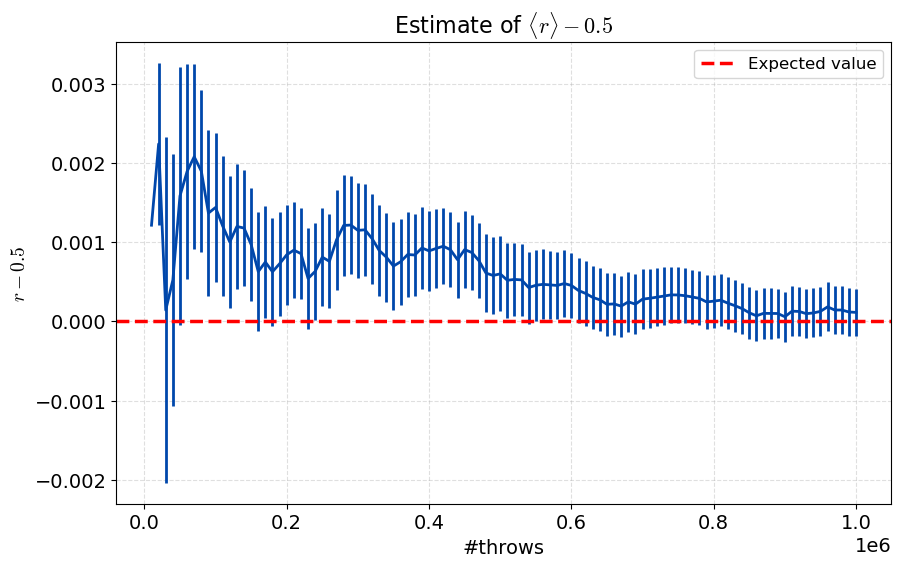

In [2]:
data = np.loadtxt("OUTPUT/risultati_01.1.1.dat")
x = data[:, 0]
y = data[:, 1]
err = data[:, 2]

plt.errorbar(x, y-0.5, yerr=err)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2.5, label='Expected value')
plt.title(r'Estimate of $\langle r \rangle - 0.5$')
plt.xlabel('#throws')
plt.ylabel(r'$r - 0.5$')
plt.legend()
plt.show()


Exercise 1.1.2

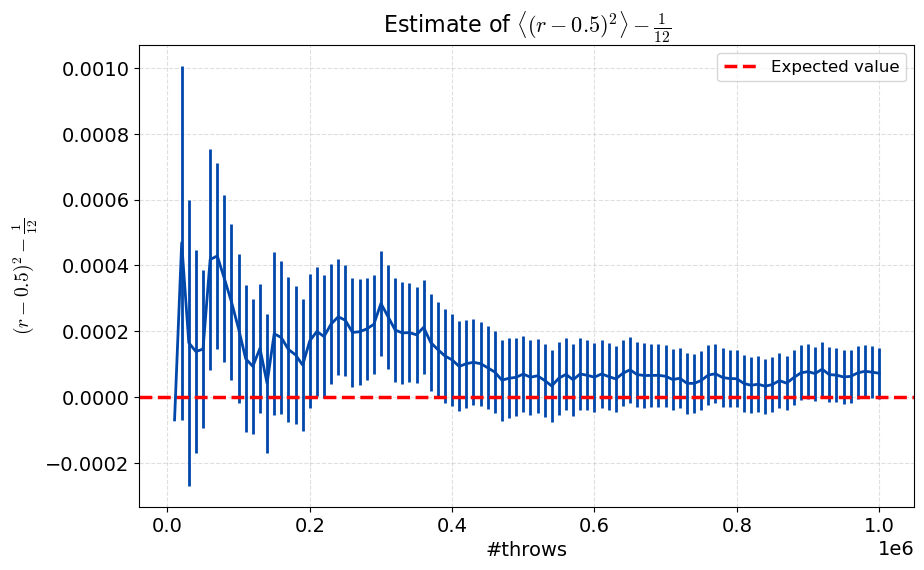

In [3]:
data = np.loadtxt("OUTPUT/risultati_01.1.2.dat")
x = data[:, 0]
y = data[:, 1]
err = data[:, 2]

plt.errorbar(x, y- 1/12, yerr=err)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2.5, label='Expected value')
plt.title(r'Estimate of $\langle (r-0.5)^2 \rangle - \frac{1}{12}$')
plt.xlabel('#throws')
plt.ylabel(r'$ (r-0.5)^2- \frac{1}{12}$')
plt.legend()
plt.show()


1.1.3: chi squared test

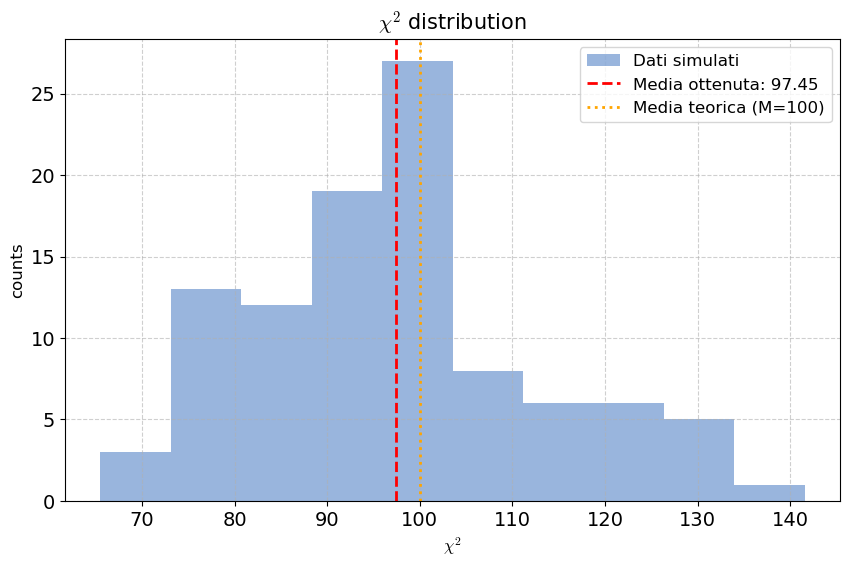

In [4]:
# Caricamento dati
data = np.loadtxt("OUTPUT/risultati_01.1.3.dat")
chi = data

# Istogramma: 'density=True' serve per confrontarlo con la curva teorica
# 'bins' impostato a 20 o 30 per una migliore risoluzione
plt.hist(chi, edgecolor='none', alpha=0.4, label='Dati simulati')

# Linea del valore atteso (Media teorica = M = 100)
plt.axvline(np.mean(chi), color='red', linestyle='--', label=f'Media ottenuta: {np.mean(chi):.2f}')
plt.axvline(100, color='orange', linestyle=':', label='Media teorica (M=100)')

# Formattazione estetica
plt.title(r'$\chi^2$ distribution', fontsize=15)
plt.xlabel(r'$\chi^2$', fontsize=12)
plt.ylabel('counts', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()


## Exercise 01.2
- Extend Pseudo-Random Number generator downloaded from the NSL Ariel web site and check the Central Limit Theorem:

1. <font color="red">Add two probability distributions</font> by using the **method of the inversion of the cumulative distribution** to sample from a **generic** <font color="red">exponential distribution</font>, $p(x) = \lambda \exp(-\lambda x)$, $x\in [0;+\infty]$ (see <a href="https://en.wikipedia.org/wiki/Exponential_distribution">this Wikipedia link</a>), and a **generic** <font color="red">Cauchy-Lorentz distribution</font> $p(x)=\frac{1}{\pi}\frac{\Gamma}{(x-\mu)^2+\Gamma^2}$, $x\in [-\infty;+\infty]$ (see <a href="https://en.wikipedia.org/wiki/Cauchy_distribution">this Wikipedia link</a>).
2. <font color="red">Make 3 pictures</font> with the histograms obtained filling them with $10^4$ realizations of $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ (for $N=1, 2, 10, 100$), being $x_i$ a random variable sampled throwing a *standard* dice (fig.1), an *exponential* dice (fig.2, use $\lambda=1$) and a *Lorentzian* dice (fig.3, use $\mu=0$ and $\Gamma=1$).

Note tha you can try to fit the case $N=100$ with a Gaussian for standard and exponential dices, whereas you should use a Cauchy-Lorentz distribution for the last case.

## Solution

In this section, after sampling $10^4$ data points from uniform, exponential, and Lorentzian distributions via the inverse transform sampling method, the distributions of the sums $S_1, S_2, S_{10}$, and $S_{100}$ (comprising 1, 2, 10, and 100 variables, respectively) are presented and compared. It is visually evident that for the uniform and exponential distributions, as the number of summands increases, the resulting distribution progressively converges toward a Gaussian profile, in full agreement with the Central Limit Theorem (CLT). Conversely, the Lorentzian distribution remains largely unchanged, confirming its property as a stable distribution and its own attractor.

### Uniform distribution

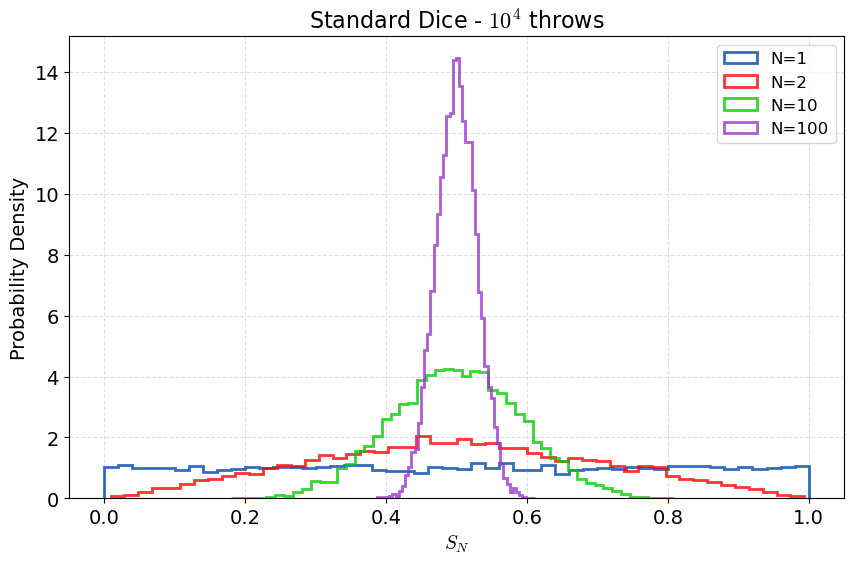

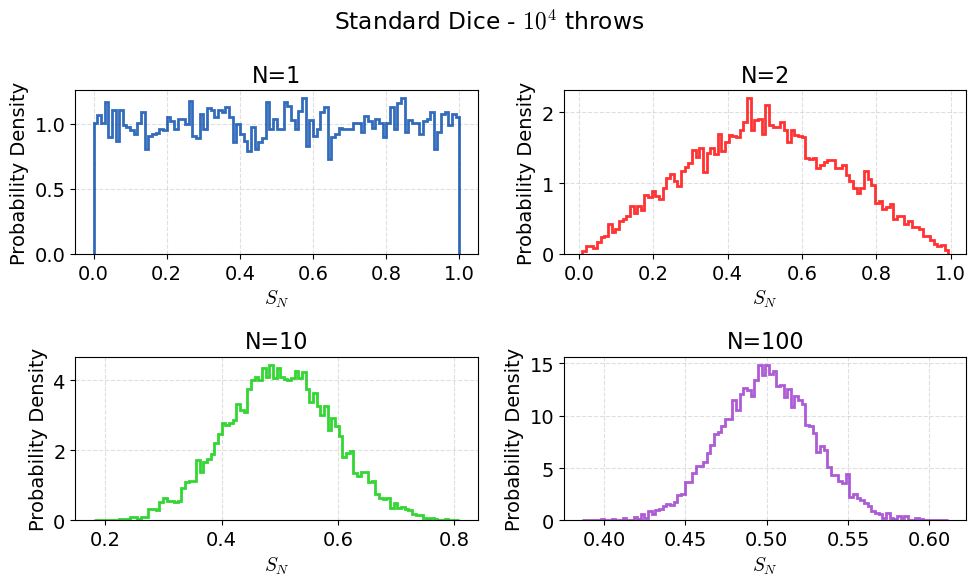

In [5]:
data = np.loadtxt("OUTPUT/standard.dat")

labels = ['N=1', 'N=2', 'N=10', 'N=100']

plt.figure()

# PLot histograms
for i in range(4):
    plt.hist(data[:, i], histtype='step', bins = 50, density=True, alpha=0.8, label=labels[i], linewidth=2)

plt.title(r"Standard Dice - $10^4$ throws")
plt.xlabel(r"$S_N$")
plt.ylabel("Probability Density")
plt.legend()
plt.show()


# Create a figure with a 2x2 grid of subplots
# figsize is slightly larger to accommodate the 4 panels nicely
fig, axes = plt.subplots(nrows=2, ncols=2)

# Flatten the 2x2 matrix of axes into a 1D array to loop through it easily
axes = axes.flatten()

# Loop through the columns of the data and the axes
for i in range(4):
    # Plot histogram in the i-th panel
    # Increased bins to 50: with 10^4 throws, 20 bins are too few!
    axes[i].hist(data[:, i], histtype='step', bins = 100, density=True, alpha=0.8, label=labels[i], linewidth=2, color=light_colors[i])
    # axes[i].hist(data[:, i], bins=500, density=True, alpha=0.7)
    
    # Set titles and labels for each subplot
    axes[i].set_title(labels[i])
    axes[i].set_xlabel(r"$S_N$")
    axes[i].set_ylabel("Probability Density")

# Add a global title to the entire figure
fig.suptitle(r"Standard Dice - $10^4$ throws")

# Automatically adjust the spacing between subplots to prevent overlapping text
plt.tight_layout()

# Show the final plot
plt.show()


### Exponential distribution

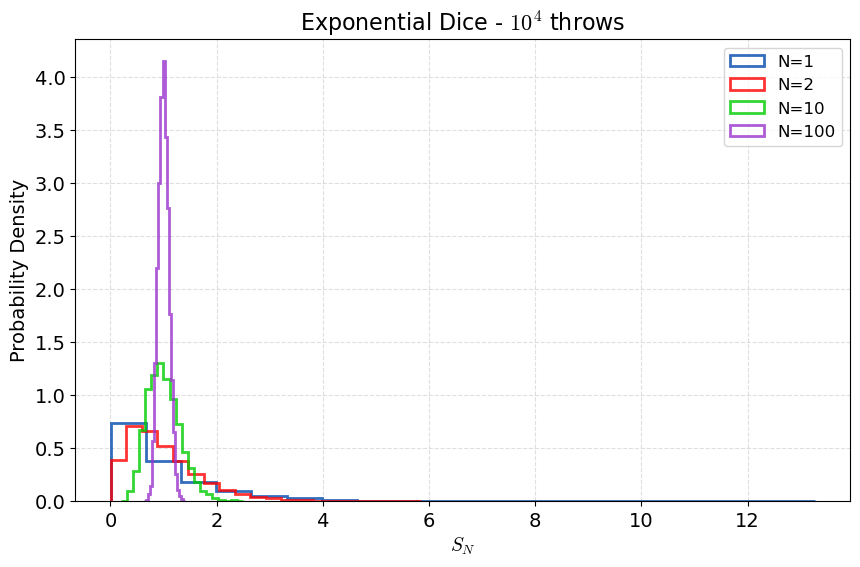

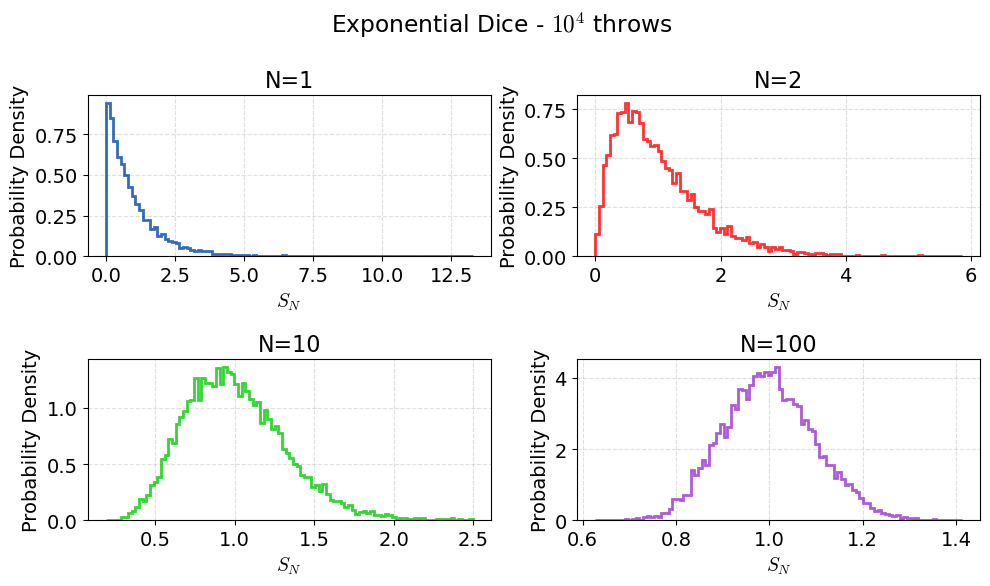

In [6]:
data = np.loadtxt("OUTPUT/exponential.dat")

labels = ['N=1', 'N=2', 'N=10', 'N=100']

plt.figure()

# Plot histograms for 1, 2, 10, 100
for i in range(4):
    plt.hist(data[:, i], histtype='step', bins = 20, density=True, alpha=0.8, label=labels[i], linewidth=2)

plt.title(r"Exponential Dice - $10^4$ throws")
plt.xlabel(r"$S_N$")
plt.ylabel("Probability Density")
plt.legend()
plt.show()


# Create a figure with a 2x2 grid of subplots
# figsize is slightly larger to accommodate the 4 panels nicely
fig, axes = plt.subplots(nrows=2, ncols=2)

# Flatten the 2x2 matrix of axes into a 1D array to loop through it easily
axes = axes.flatten()

# Loop through the columns of the data and the axes
for i in range(4):
    # Plot histogram in the i-th panel
    # Increased bins to 50: with 10^4 throws, 20 bins are too few!
    axes[i].hist(data[:, i], histtype='step', bins = 100, density=True, alpha=0.8, label=labels[i], linewidth=2, color=light_colors[i])
    # axes[i].hist(data[:, i], bins=500, density=True, alpha=0.7)
    
    # Set titles and labels for each subplot
    axes[i].set_title(labels[i])
    axes[i].set_xlabel(r"$S_N$")
    axes[i].set_ylabel("Probability Density")

# Add a global title to the entire figure
fig.suptitle(r"Exponential Dice - $10^4$ throws")

# Automatically adjust the spacing between subplots to prevent overlapping text
plt.tight_layout()

# Show the final plot
plt.show()


### Lorentzian distribution

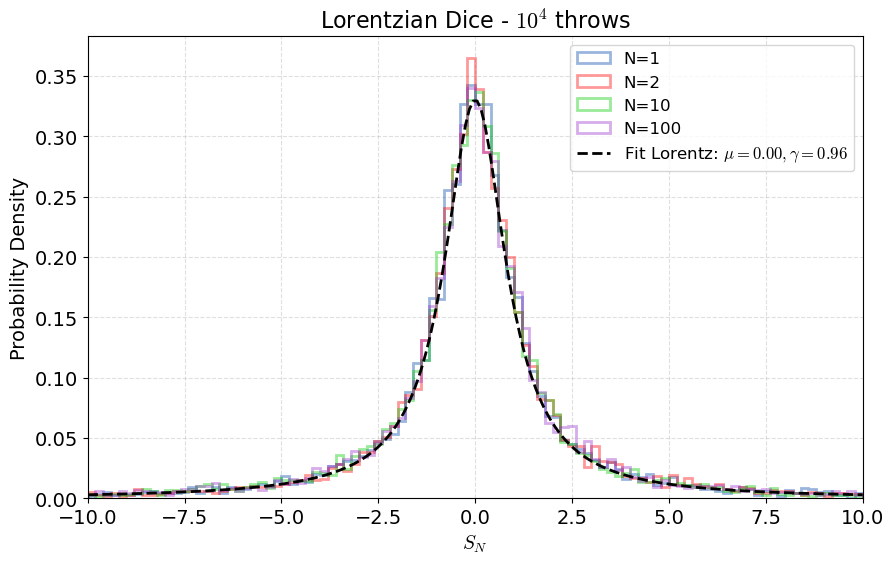

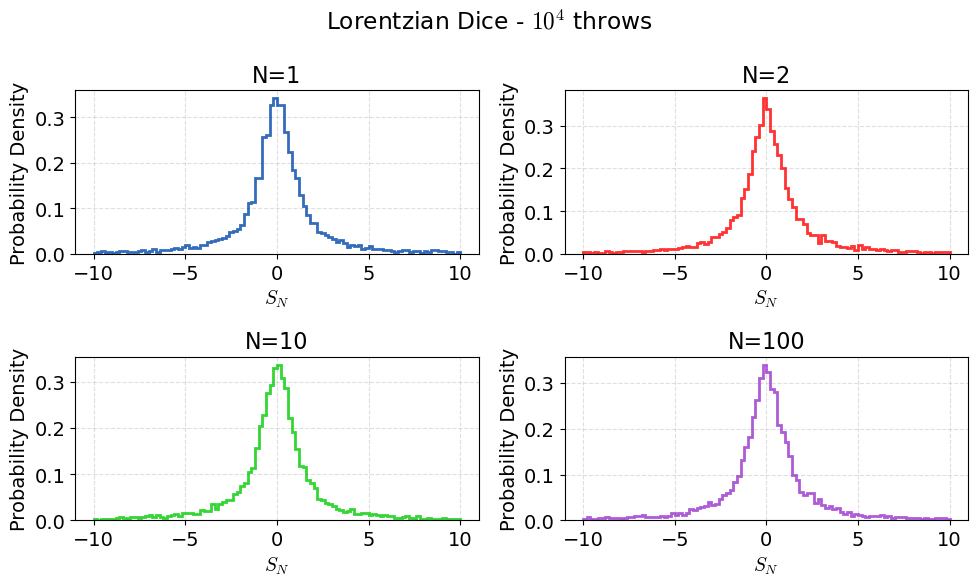

In [7]:
from scipy.optimize import curve_fit

data = np.loadtxt("OUTPUT/lorentzian.dat")

labels = ['N=1', 'N=2', 'N=10', 'N=100']

plt.figure()

# Plot histograms for 1, 2, 10, 100
for i in range(4):
    plt.hist(data[:, i], range=(-10, 10), histtype='step', bins = 100, density=True, alpha=0.4, label=labels[i], linewidth=2)

def lorentzian(x, mu, gamma):
    return (1/np.pi) * (gamma / ((x - mu)**2 + gamma**2))

# -- Preparazione dei dati per il fit (prendiamo l'istogramma N=100)
# Calcoliamo i bin dell'istogramma per avere dei punti (x, y) da fittare
counts, bin_edges = np.histogram(data[:, 3], bins=100, range=(-10, 10), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 3. Esecuzione del Fit
popt, pcov = curve_fit(lorentzian, bin_centers, counts, p0=[0, 1]) # p0 sono i valori iniziali [mu, gamma]

x_fit = np.linspace(-10, 10, 200)
plt.plot(x_fit, lorentzian(x_fit, *popt), color='black', linestyle='--', 
         label=f'Fit Lorentz: $\mu={popt[0]:.2f}, \gamma={popt[1]:.2f}$')


plt.title(r"Lorentzian Dice - $10^4$ throws")
plt.xlabel(r"$S_N$")
plt.ylabel("Probability Density")
# Aggiungi plt.xlim(-10, 10) per vedere bene il picco, dato che la Lorentz ha code lunghissime
plt.xlim(-10, 10)
plt.legend()
plt.show()


# Create a figure with a 2x2 grid of subplots
# figsize is slightly larger to accommodate the 4 panels nicely
fig, axes = plt.subplots(nrows=2, ncols=2)

# Flatten the 2x2 matrix of axes into a 1D array to loop through it easily
axes = axes.flatten()

# Loop through the columns of the data and the axes
for i in range(4):
    # Plot histogram in the i-th panel
    # Increased bins to 50: with 10^4 throws, 20 bins are too few!
    axes[i].hist(data[:, i], range=(-10, 10), histtype='step', bins = 100, density=True, alpha=0.8, label=labels[i], linewidth=2, color=light_colors[i])
    # axes[i].hist(data[:, i], bins=500, density=True, alpha=0.7)
    
    # Set titles and labels for each subplot
    axes[i].set_title(labels[i])
    axes[i].set_xlabel(r"$S_N$")
    axes[i].set_ylabel("Probability Density")

# Add a global title to the entire figure
fig.suptitle(r"Lorentzian Dice - $10^4$ throws")

# Automatically adjust the spacing between subplots to prevent overlapping text
plt.tight_layout()

# Show the final plot
plt.show()

## Exercise 1.3
### Buffon's experiment

In the final exercise, I simulated Buffon's needle experiment, successfully obtaining a reliable estimate of $\pi$. This result not only validates the theoretical model underlying the experiment but also provides further confirmation of the robustness of the RNG.

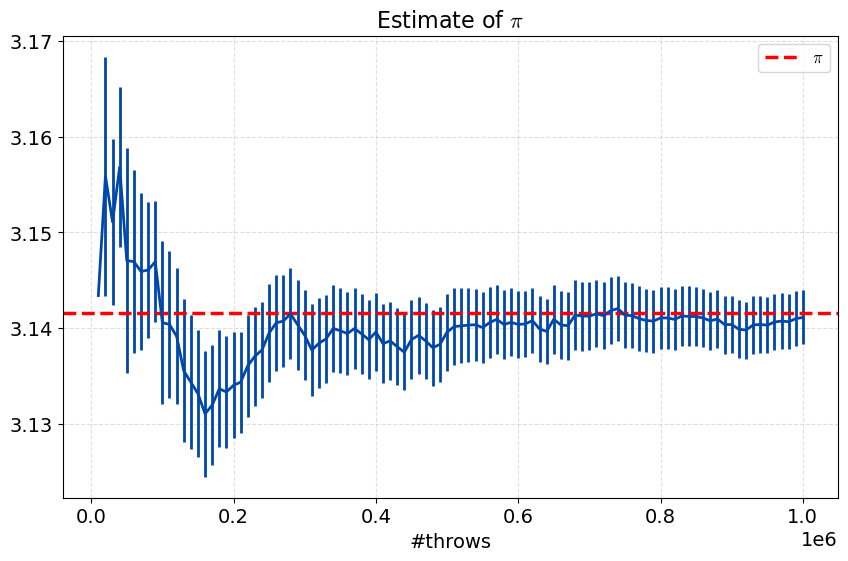

In [8]:
data = np.loadtxt("OUTPUT/risultati_01.3.dat")
x = data[:, 0]
y = data[:, 1]
err = data[:, 2]

plt.errorbar(x, y, yerr=err)
plt.axhline(y=np.pi, color='red', linestyle='--', linewidth=2.5, label='$\pi$')
plt.title(r'Estimate of $\pi$')
plt.xlabel('#throws')
plt.legend()
plt.show()